# My Content Action Playbook

This playbook turns the validated March output into a small, human-reviewed research workflow. It is for **Refresh / Content Opportunity Scoring**, with an editor deciding what to inspect before changing content.

The Week 6 audit supports using the model's out-of-fold ordering in this exercise. It does not show that refreshing pages prevents decline. These are historical March examples with pseudonymous IDs; the release has no identity mapping that would let me apply edits to real pages.

## 1. Ranked actions and reason codes

I keep the client-grouped out-of-fold scores from Week 6. Each labelled page was scored by a model trained on other clients. Scores are useful for ordering **within a client**, not for moving editorial capacity between clients or treating different fold models as equally calibrated.

I start with up to **20 reviews per client per cycle**. Pages further down the queue stay under monitoring. The reason codes below describe earlier measurements and the suggested review route; they are simple explanations for the action, not an exact attribution of the logistic score.

| Descriptive archetype | Earlier measurements | Suggested human action | Reason code |
|---|---|---|---|
| Visible, weak click capture | Position 1–20 and CTR below 0.5% | Inspect the snippet and search intent, then check whether a content change is needed | `low_ctr_at_visible_position` |
| Limited search position | Position above 20 | Check relevance and internal-link context before considering an edit | `limited_search_position` |
| Established visibility | Position 1–20 with CTR at least 0.5% | Check facts and recent search context; monitor if no issue is found | `visible_page_review` |
| Position unavailable | Missing usable position | Verify measurement before any content action | `missing_position` |

These are rule-defined workflow groups, not semantic clusters or proof that a particular edit will work.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

needed = {"duckdb": "duckdb", "huggingface_hub": "huggingface_hub", "sklearn": "scikit-learn",
          "pyarrow": "pyarrow", "matplotlib": "matplotlib", "pandas": "pandas"}
missing = [package for module, package in needed.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
root = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "work/lane_utils.py").is_file()), None)
if root is None:
    if importlib.util.find_spec("google.colab") is None:
        raise RuntimeError("Open this notebook inside your repository checkout.")
    root = Path("/content/FlyrankAI-Internship")
    if not root.exists():
        subprocess.check_call(["git", "clone", "--depth", "1",
            "https://github.com/vibhanshu-s/FlyrankAI-Internship.git", str(root)])
sys.path.insert(0, str(root / "work"))
import lane_utils as u
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

pages = u.load_pages(root)
experiment = u.labelled_pages(pages)
train_index, test_index = u.grouped_split(experiment)
training = experiment.iloc[train_index].copy()
test = experiment.iloc[test_index].copy()
print(f"March review pool: {len(pages):,} pages; known outcomes: {len(experiment):,}; unknown: {pages.future_decline.isna().sum():,}.")
print(f"Fixed client split: {len(training):,} training pages / {len(test):,} test pages.")
print("Features stop March 14; assumed decision March 18; labels use March 18–31. June remains sealed.")

March review pool: 60,534 pages; known outcomes: 57,459; unknown: 3,075.
Fixed client split: 14,070 training pages / 43,389 test pages.
Features stop March 14; assumed decision March 18; labels use March 18–31. June remains sealed.


In [2]:
import json
from sklearn.model_selection import GroupKFold
audit = json.loads((root / "work/outputs/w06_validation_metrics.json").read_text(encoding="utf-8"))
assert audit["contract"] == u.CONTRACT and audit["baseline"] == u.BASELINE
assert audit["data_fingerprint"] == u.fingerprint(pages)
oof_path = root / "work/outputs/w06_oof_predictions.parquet"
if oof_path.is_file():
    oof_frame = pd.read_parquet(oof_path)
else:
    # Regenerate the ignored predictions when running from a fresh checkout.
    oof_frame = experiment.copy()
    predictions = np.full(len(experiment), np.nan)
    folds = np.zeros(len(experiment), dtype=int)
    for fold, (fit_rows, score_rows) in enumerate(GroupKFold(n_splits=5).split(
            experiment[u.FEATURES], experiment.future_decline.astype(int), experiment.client_hash_id), 1):
        assert set(experiment.iloc[fit_rows].client_hash_id).isdisjoint(set(experiment.iloc[score_rows].client_hash_id))
        fitted = u.make_model()
        fitted.fit(experiment.iloc[fit_rows][u.FEATURES], experiment.iloc[fit_rows].future_decline.astype(int))
        predictions[score_rows] = fitted.predict_proba(experiment.iloc[score_rows][u.FEATURES])[:, 1]
        folds[score_rows] = fold
    assert np.isfinite(predictions).all()
    oof_frame["oof_score"], oof_frame["fold"] = predictions, folds
    oof_frame.to_parquet(oof_path, index=False)
assert u.fingerprint(oof_frame, u.KEYS) == audit["oof_keys_sha256"]
assert u.fingerprint(oof_frame, ["oof_score", "fold"]) == audit["oof_scores_sha256"], "Rerun Week 6 if library changes produce new predictions."

public_columns = u.KEYS + u.FEATURES + ["earlier_impressions"]
scores = (oof_frame.oof_score.to_numpy() if audit["selected_method"] == "logistic_regression_oof"
          else u.rule_score(oof_frame))
queue = u.rank_frame(oof_frame[public_columns], scores)
missing_position = queue.weighted_position.isna()
weak_capture = queue.weighted_position.between(1, 20) & queue.ctr_pct.lt(0.5)
deep_position = queue.weighted_position.gt(20)
queue["archetype"] = np.select([missing_position, weak_capture, deep_position],
    ["position_unavailable", "visible_weak_click_capture", "limited_search_position"], default="established_visibility")
queue["reason_code"] = np.select([missing_position, weak_capture, deep_position],
    ["missing_position", "low_ctr_at_visible_position", "limited_search_position"], default="visible_page_review")
queue["review_route"] = np.select([missing_position, weak_capture, deep_position],
    ["verify_measurement", "inspect_snippet_and_intent", "inspect_relevance_and_internal_links"], default="check_facts_and_search_context")
queue["action"] = np.where(queue.client_rank.le(20), queue.review_route, "monitor")
queue["human_review_required"] = True
queue["evidence_scope"] = "historical_March_cross_client_research"
queue["decision_date_assumed"] = u.CONTRACT["decision_date"]
queue["feature_window_end"] = u.CONTRACT["feature_window"][1]
assert set(queue.columns).isdisjoint({"future_decline", "later_impressions", "later_days"})
assert queue.groupby("client_hash_id").score.apply(lambda s: s.is_monotonic_decreasing).all()
assert not queue.duplicated(u.KEYS).any()

shortlist = queue.loc[queue.client_rank.le(20)]
preview = shortlist.groupby("client_hash_id", sort=False).head(1).head(10)
display(preview[u.KEYS + ["client_rank", "score", "archetype", "reason_code", "action"]])
display(queue.groupby("archetype").agg(pages=("score", "size"),
    typical_earlier_impressions=("earlier_impressions", "median")))
print(f"Method carried forward: {audit['selected_method']}; {len(queue):,} historical queue rows; {len(shortlist)} budgeted reviews.")
print("Preview shows one first-ranked page per client, not a global allocation of review capacity.")

,client_hash_id,content_hash_id,client_rank,score,archetype,reason_code,action
4,client_0797ff3a1fc9a6a5,content_be06033d30b49299,1,0.687224,limited_search_position,limited_search_position,inspect_relevance_and_internal_links
733,client_08a6a72ff48e62c0,content_3a84ab97e741f758,1,0.671200,visible_weak_click_capture,low_ctr_at_visible_position,inspect_snippet_and_intent
3224,client_08d2847f24cf89c1,content_907ea9ba9b787a4d,1,0.321635,visible_weak_click_capture,low_ctr_at_visible_position,inspect_snippet_and_intent
3226,client_0e1acc6cd57b0eba,content_2abf26b922d62f2b,1,0.316420,visible_weak_click_capture,low_ctr_at_visible_position,inspect_snippet_and_intent
3263,client_0fa64a184f18a4a0,content_7458ba83f9433f6b,1,0.500976,visible_weak_click_capture,low_ctr_at_visible_position,inspect_snippet_and_intent
3652,client_157ffe4d4a595515,content_f9119f7626a7b281,1,0.663404,limited_search_position,limited_search_position,inspect_relevance_and_internal_links
3924,client_1a730cb2640a1abf,content_b9d46abd9ffa6c8a,1,0.648509,visible_weak_click_capture,low_ctr_at_visible_position,inspect_snippet_and_intent
4273,client_20259bd6705d81d4,content_1a50db90f6be0514,1,0.770930,limited_search_position,limited_search_position,inspect_relevance_and_internal_links
6649,client_2094c6eb080311d5,content_7fa5d34834e200fe,1,0.549878,visible_weak_click_capture,low_ctr_at_visible_position,inspect_snippet_and_intent
13732,client_23a62021009f63c4,content_b875a2f306635a58,1,0.824755,limited_search_position,limited_search_position,inspect_relevance_and_internal_links


,pages,typical_earlier_impressions
archetype,,
established_visibility,10111,717.0
limited_search_position,11167,727.0
visible_weak_click_capture,36181,705.0


Method carried forward: logistic_regression_oof; 57,459 historical queue rows; 504 budgeted reviews.
Preview shows one first-ranked page per client, not a global allocation of review capacity.


## 2. Intended use and limits

**Who uses it:** An editor or search analyst can use this exercise to practise choosing a manageable review list and asking why a page was suggested. An authorised editor would still need to check the actual page and its own search context; I cannot recover that content from pseudonymous IDs.

**Decay and refresh insight:** Earlier demand and weak click capture can point to pages worth investigating. A later fall in impressions can also come from seasonality, changed query demand, result-page changes, or an earlier temporary spike. My five features do not include historical update age, and I did not observe refresh interventions. I cannot identify age-driven decay or estimate refresh benefit. Refresh is a possible action only after a person finds outdated or incomplete content.

**Cost and value:** I assume 15 minutes for an initial review, so a 20-page list represents about five editor hours per client per cycle. This is a planning assumption, not measured labour cost. A wrong pick spends some of that time on a page that may not need attention; a missed page may wait longer for diagnosis. The measured gain below means more decline-proxy hits in this sample, not recovered traffic or revenue.

**Scope:** The main queue covers the 57,459 pages with complete later coverage because that is the audited population. I keep the 3,075 other earlier-eligible pages in a separate, unscored coverage follow-up list. That follow-up is retrospective: its missing-outcome status was not known on March 18. It must not be mixed into the validated model queue or described as part of its measured precision.

The model learned from other clients' later March labels, so the assumed March decision is an offline replay, not a model genuinely available that day. This month has already been explored. A new-period claim needs an earlier completed training window and a later untouched test.

In [3]:
coverage_followup = pages.loc[pages.future_decline.isna(), public_columns].copy()
coverage_followup["action"] = "verify_tracking_history"
coverage_followup["reason_code"] = "later_coverage_unverified"
coverage_followup["evidence_scope"] = "retrospective_coverage_followup_not_validated_risk"
coverage_followup["human_review_required"] = True
display(pd.DataFrame({"population": ["Audited historical queue", "Retrospective coverage follow-up"],
    "pages": [len(queue), len(coverage_followup)],
    "clients": [queue.client_hash_id.nunique(), coverage_followup.client_hash_id.nunique()]}))
gain = audit["paired_client_gain"]["mean"]
display(Markdown(
    f"**Observed comparison:** Mean OOF precision@20 was "
    f"{100 * audit['oof_metrics']['Logistic regression / all OOF pages']['macro_precision_at_20']:.2f}% for the model "
    f"and {100 * audit['oof_metrics']['Frozen rule / all OOF pages']['macro_precision_at_20']:.2f}% for the rule "
    f"across {audit['paired_client_gain']['full_queue_clients']} full-list clients. "
    f"That is roughly {20 * gain:.1f} more later-decline flags per 20 selections on average. "
    "It is not a count of successful edits."))
print("Review-time assumption: 20 × 15 minutes = 5 hours per full client list.")
print("Estimated traffic or financial gain: not available from this dataset.")

,population,pages,clients
0,Audited historical queue,57459,32
1,Retrospective coverage follow-up,3075,29


**Observed comparison:** Mean OOF precision@20 was 57.17% for the model and 38.26% for the rule across 23 full-list clients. That is roughly 3.8 more later-decline flags per 20 selections on average. It is not a count of successful edits.

Review-time assumption: 20 × 15 minutes = 5 hours per full client list.
Estimated traffic or financial gain: not available from this dataset.


## 3. Human review and the no-go list

Before acting, an editor should check measurement coverage, the relevant query mix in their own authorised tools, current search intent, device/country differences, and whether the actual content contains an issue. Record one outcome for each review: accept for further investigation, monitor, or reject with a reason. A snippet, relevance, or fact-check recommendation is still only an inspection route.

**What should not be automated:** Rewriting, publishing, deleting, pruning, merging URLs, changing canonical tags, or spending money based on this score. Do not turn a low score into a claim that a page has no value. Do not use missing tracking as zero traffic, or infer client identities from hashes. No page-level action should be applied without a person reviewing the real content.

I would also hold back a recommendation when the review window is incomplete, the reporting delay is uncertain, an editor finds an important business purpose the metrics miss, or a major search/measurement change makes the old context unreliable. The March exports are historical research artefacts and should not be presented as today's live queue.

In [4]:
review_checks = pd.DataFrame([
    ["Coverage", "Are measurements complete and the reporting delay understood?", "Pause if not"],
    ["Search context", "Does low CTR persist within the relevant query, device, and country context?", "Inspect before editing"],
    ["Content", "Is information actually outdated, incomplete, or misleading?", "Refresh only if a real issue is found"],
    ["Business purpose", "Would the proposed change harm a useful page or a strategic goal?", "Editor decides"],
    ["Follow-up", "Was a review accepted, rejected, or left for monitoring, and why?", "Record feedback"],
], columns=["check", "question", "human_rule"])
display(review_checks)
assert queue.human_review_required.all() and coverage_followup.human_review_required.all()
assert queue.action.isin(["verify_measurement", "inspect_snippet_and_intent",
    "inspect_relevance_and_internal_links", "check_facts_and_search_context", "monitor"]).all()
print("No automatic edit, delete, publish, merge, or budget-spend action is exported.")

,check,question,human_rule
0,Coverage,Are measurements complete and the reporting de...,Pause if not
1,Search context,Does low CTR persist within the relevant query...,Inspect before editing
2,Content,"Is information actually outdated, incomplete, ...",Refresh only if a real issue is found
3,Business purpose,Would the proposed change harm a useful page o...,Editor decides
4,Follow-up,"Was a review accepted, rejected, or left for m...",Record feedback


No automatic edit, delete, publish, merge, or budget-spend action is exported.


## 4. Monitoring and retrain triggers

This is a proposal for a small research pilot, not a deployed monitoring system. I would check data availability every review cycle and evaluate the decline proxy only after the later window and reporting lag have completed.

- Pause the queue when feature coverage is incomplete or tracking definitions change; verify the data before retraining.
- Investigate if missing position exceeds 5% of eligible pages or unlabelled outcomes exceed 10%. These are proposed alarms, not thresholds validated by this study.
- Review the rule and model if mean precision@20 falls below the frozen rule on two completed evaluation periods, using the same eligibility and capacity rules.
- Inspect changes when the decline base rate shifts by more than ten percentage points or the signal distributions change substantially. Check causes before fitting again.
- If fewer than half of at least 20 editor reviews are accepted for further investigation over two cycles, revisit the action mapping. Acceptance is not measured yet and is not the same as traffic lift.

Retraining would use only periods whose outcomes have already completed. It would require a new data contract, a later grouped/time-aware check, and human sign-off. The final month remains reserved; I do not use it to choose features, thresholds, or models here.

In [5]:
monitoring_plan = {
    "status": "proposed research monitoring; not deployed",
    "review_capacity_per_client": 20,
    "assumed_initial_review_minutes": 15,
    "pause_on_incomplete_feature_coverage": True,
    "investigate_missing_position_fraction_above": 0.05,
    "investigate_unknown_outcome_fraction_above": 0.10,
    "investigate_base_rate_change_absolute": 0.10,
    "compare_model_to_rule_after_completed_periods": 2,
    "editor_feedback_minimum_reviews": 20,
    "investigate_acceptance_fraction_below": 0.50,
    "automatic_retraining": False,
    "automatic_content_changes": False,
}
display(pd.DataFrame({"reference_measure": ["Unknown later-outcome fraction", "Missing earlier-position fraction"],
    "March_value": [pages.future_decline.isna().mean(), pages.weighted_position.isna().mean()],
    "proposed_investigation_threshold": [0.10, 0.05]}).round(4))
print("No monitoring runs or retraining jobs are scheduled; triggers are a practical proposal.")

,reference_measure,March_value,proposed_investigation_threshold
0,Unknown later-outcome fraction,0.0508,0.10
1,Missing earlier-position fraction,0.0000,0.05


No monitoring runs or retraining jobs are scheduled; triggers are a practical proposal.


## 5. Exports for the paper

The notebook writes `work/outputs/action_playbook_queue.csv` and `work/outputs/coverage_followup_queue.csv`. Both remain ignored by git and are regenerated on each run. Neither includes later impressions or labels.

The committed `w07_playbook_metrics.json` records the method, data fingerprints, source receipt hashes, counts, monitoring assumptions, and export checksums. The reusable figure is committed under `work/figures/`, as the assignment asks. Its caption names the exact comparison and population. These files can support a later paper, without turning an observational result into a claim that editing causes recovery.

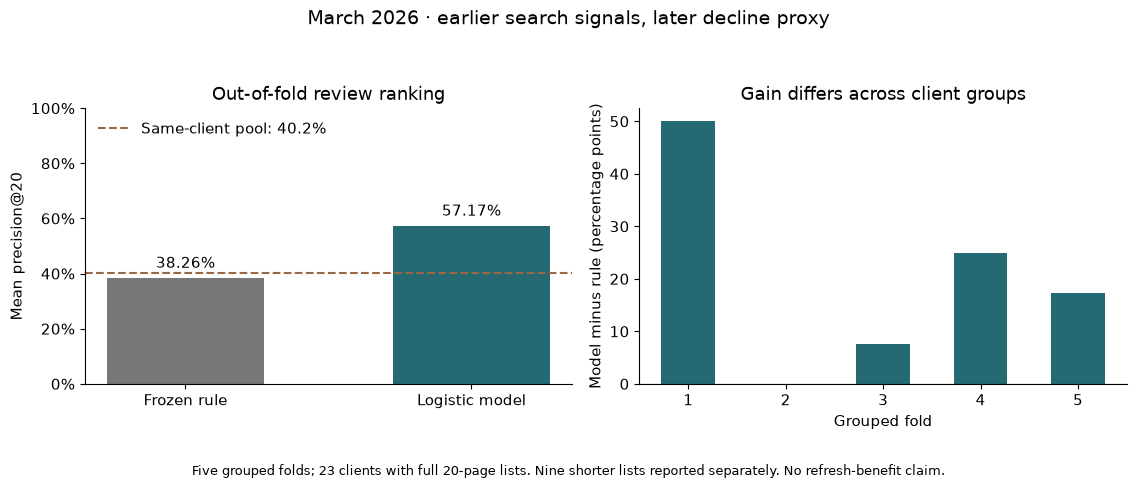

Exported 57,459 main queue rows and 3,075 coverage follow-up rows.
Committed paper inputs: aggregate JSON receipts and work/figures/model_vs_baseline_precision.png.
CSV files and the warehouse/prediction caches remain outside git.


In [6]:
import hashlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

output_dir = root / "work/outputs"
figure_dir = root / "work/figures"
figure_dir.mkdir(parents=True, exist_ok=True)
main_csv = output_dir / "action_playbook_queue.csv"
coverage_csv = output_dir / "coverage_followup_queue.csv"
queue.to_csv(main_csv, index=False)
coverage_followup.to_csv(coverage_csv, index=False)
assert len(pd.read_csv(main_csv)) == len(queue)
assert len(pd.read_csv(coverage_csv)) == len(coverage_followup)
assert set(queue.columns).isdisjoint({"future_decline", "later_impressions", "later_days"})
assert set(coverage_followup.columns).isdisjoint({"future_decline", "later_impressions", "later_days"})

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
rule_precision = audit["oof_metrics"]["Frozen rule / all OOF pages"]["macro_precision_at_20"]
model_precision = audit["oof_metrics"]["Logistic regression / all OOF pages"]["macro_precision_at_20"]
pool_rate = audit["oof_metrics"]["Logistic regression / all OOF pages"]["macro_base_rate_same_clients"]
bars = axes[0].bar(["Frozen rule", "Logistic model"], [rule_precision, model_precision], color=["#777777", "#256A72"], width=0.55)
axes[0].axhline(pool_rate, color="#9A6842", linestyle="--", label=f"Same-client pool: {pool_rate:.1%}")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_ylabel("Mean precision@20")
axes[0].set_title("Out-of-fold review ranking")
axes[0].bar_label(bars, labels=[f"{value:.2%}" for value in [rule_precision, model_precision]], padding=5)
axes[0].legend(frameon=False, loc="upper left")
gains = np.array(audit["fold_gains"]) * 100
axes[1].bar(range(1, 6), gains, color="#256A72", width=0.55)
axes[1].axhline(0, color="#555555", linewidth=0.8)
axes[1].set_xticks(range(1, 6))
axes[1].set_xlabel("Grouped fold")
axes[1].set_ylabel("Model minus rule (percentage points)")
axes[1].set_title("Gain differs across client groups")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("March 2026 · earlier search signals, later decline proxy", fontsize=14)
fig.text(0.5, 0.01, "Five grouped folds; 23 clients with full 20-page lists. Nine shorter lists reported separately. No refresh-benefit claim.",
         ha="center", fontsize=9)
fig.tight_layout(rect=[0, 0.07, 1, 0.93])
figure = figure_dir / "model_vs_baseline_precision.png"
fig.savefig(figure, dpi=180, bbox_inches="tight")
display(fig)
plt.close(fig)

source_files = ["w04_baseline_metrics.json", "w05_model_metrics.json", "w06_validation_metrics.json"]
source_hashes = {name: hashlib.sha256((output_dir / name).read_bytes()).hexdigest() for name in source_files}
receipt = {"contract": u.CONTRACT, "data_fingerprint": u.fingerprint(pages),
    "selected_method": audit["selected_method"], "validated_metrics": audit["oof_metrics"],
    "paired_client_gain": audit["paired_client_gain"], "source_receipts_sha256": source_hashes,
    "main_queue_rows": len(queue), "main_queue_clients": int(queue.client_hash_id.nunique()),
    "coverage_followup_rows": len(coverage_followup), "budgeted_reviews": len(shortlist),
    "archetype_counts": {str(k): int(v) for k, v in queue.archetype.value_counts().items()},
    "action_counts": {str(k): int(v) for k, v in queue.action.value_counts().items()},
    "monitoring_plan": monitoring_plan,
    "exports": {"main_queue": str(main_csv.relative_to(root)), "coverage_followup": str(coverage_csv.relative_to(root)),
        "figure": str(figure.relative_to(root)),
        "main_queue_sha256": hashlib.sha256(main_csv.read_bytes()).hexdigest(),
        "coverage_queue_sha256": hashlib.sha256(coverage_csv.read_bytes()).hexdigest()},
    "artifact_status": "historical research exercise; not current recommendations or a deployed model",
    "no_automatic_content_changes": True,
    "no_causal_refresh_or_revenue_claim": True}
u.write_receipt(root, "w07_playbook_metrics.json", receipt)
print(f"Exported {len(queue):,} main queue rows and {len(coverage_followup):,} coverage follow-up rows.")
print("Committed paper inputs: aggregate JSON receipts and work/figures/model_vs_baseline_precision.png.")
print("CSV files and the warehouse/prediction caches remain outside git.")

## 6. Self-check

- [x] I carried forward the audited method and out-of-fold scores without fitting on each scored client's pages.
- [x] I gave ranked review actions, reason codes, and descriptive archetype-to-action mapping.
- [x] I stated who uses the result and the short-window, coverage, timing, and identity-mapping limits.
- [x] I explained the decline/refresh distinction, review cost assumptions, and no-go actions.
- [x] I proposed practical monitoring and retraining triggers without deploying them.
- [x] The notebook regenerates the queues, aggregate receipt, and reusable figure.
- [x] It ran top to bottom, and the notebook, metrics JSON, and figure are included in the commit.
- [x] CSVs, raw data, predictions, and credentials remain out of git; claims are decision-support only.